# Notebook 2: Logit Lens
**Kurs:** Mechanistic Interpretability  
**Modell:** EleutherAI/pythia-410m  
**Ziel:** Vorhersagen nach jeder Schicht visualisieren.

## Hintergrund: Was ist der Logit Lens?

Der **Logit Lens** (nostalgebraist, 2020) ist eine Technik, um zu sehen, was ein Transformer "nach jeder Schicht denkt".

**Kernidee:** Transformer haben einen **Residual Stream** â€” ein Informationskanal, der durch alle Schichten flieÃŸt. Jede Schicht *addiert* ihren Beitrag.

Da der finale Output die letzte Projektion des Residual Streams auf den Vokabular-Raum ist, kÃ¶nnen wir dieselbe **Unembed-Matrix W_U** auch auf frÃ¼here Hidden States anwenden:

```
Logit Lens bei Schicht L: logits_L = hidden_state_L @ W_U.T
```

So sehen wir, wie sich die Vorhersage Ã¼ber die Schichten herausbildet.

**Frage:** In welcher Schicht "weiÃŸ" das Modell die richtige Antwort?

## 1. Setup und Modell laden

In [12]:
%load_ext autoreload
%autoreload 2

# Standard-library imports used only for notebook bootstrapping.
# The analysis logic itself lives in the utility modules imported below.
import sys
import importlib
from pathlib import Path
from IPython.display import Image, display

# The notebook is stored in assignement/notebooks, while reusable Python
# modules are stored in assignement/utils. Adding that folder to sys.path lets
# the notebook import project utilities without duplicating implementation code.
utils_dir = Path.cwd().parent / "utils"
if not (utils_dir / "config.py").exists():
    raise FileNotFoundError(f"Could not find the assignment utils directory: {utils_dir}")

if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

# Import the small set of modules needed for this notebook. The autoreload
# extension plus explicit reloads make notebook reruns pick up utility edits.
import config
import model_utils
import plotting_utils
import logit_lens_utils

for module in [
    config,
    model_utils,
    plotting_utils,
    logit_lens_utils,
]:
    importlib.reload(module)

# Keep the notebook readable by importing only high-level orchestration
# functions. Heavy computation and plotting stay in the utility files.
from model_utils import load_model_and_tokenizer, setup_environment
from logit_lens_utils import (
    analyze_hu_liu_logit_sentiment_scores,
    analyze_hu_liu_sentiment_probability_mass,
    logit_lens_all_layers,
    print_first_hu_liu_sentiment_token,
    print_layer_top1_table,
    prepare_hu_liu_sentiment_state,
    print_top_tokens_for_final_layer,
    run_prompt_pair_forward_passes,
    save_logit_lens_heatmaps,
    unembedding_matrix,
)

# Select the available device and load the same model/tokenizer pair used in
# the rest of the assignment.
device = setup_environment()
model, tokenizer = load_model_and_tokenizer(device)

# Display helper for PNG files produced by plotting utilities. Plot functions
# save images to config.OUTPUT_PNG_DIR; the notebook only displays them.
def display_image(png_name):
    image_path = config.OUTPUT_PNG_DIR / png_name
    if not image_path.exists():
        raise FileNotFoundError(f"PNG image not found in output directory: {image_path}")
    display(Image(filename=str(image_path)))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch-Version : 2.6.0+cu124
Gerät           : cpu


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


Modell-Architektur:
GPTNeoXForCausalLM(
  (gpt_neox): GPTNeoXModel(
    (embed_in): Embedding(50304, 1024)
    (emb_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-23): 24 x GPTNeoXLayer(
        (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_dropout): Dropout(p=0.0, inplace=False)
        (post_mlp_dropout): Dropout(p=0.0, inplace=False)
        (attention): GPTNeoXAttention(
          (query_key_value): Linear(in_features=1024, out_features=3072, bias=True)
          (dense): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (mlp): GPTNeoXMLP(
          (dense_h_to_4h): Linear(in_features=1024, out_features=4096, bias=True)
          (dense_4h_to_h): Linear(in_features=4096, out_features=1024, bias=True)
          (act): GELUActivation()
        )
      )
    )
    (final_layer_norm): LayerNorm

## 2. Forward Pass mit Hidden States

In [ ]:
# Define a simple sentiment prompts pair
# Wrap both strings in the same prompt-pair structure used by the utility functions
prompt_pair = {
    "id": "user_defined_positive_negative_pair",
    "positive": "The food was tasty and I felt very",
    "negative": "The food was disgusting and I felt very",
}

# Run both prompts through the model with output_hidden_states=True.
# The utility returns one hidden-state tensor for the embedding output plus one
# tensor after each transformer layer, separately for the positive and negative
# prompt.
positive_hidden_states, negative_hidden_states = run_prompt_pair_forward_passes(
    model,
    tokenizer,
    device,
    prompt_pair,
)



Positive prompt
Number of hidden states: 25
Expected: model layers + 1 embedding state
Hidden state 0: (1, 8, 1024)
Hidden state 1: (1, 8, 1024)
Hidden state 2: (1, 8, 1024)
Hidden state 3: (1, 8, 1024)
Hidden state 4: (1, 8, 1024)
Hidden state 5: (1, 8, 1024)
Hidden state 6: (1, 8, 1024)
Hidden state 7: (1, 8, 1024)
Hidden state 8: (1, 8, 1024)
Hidden state 9: (1, 8, 1024)
Hidden state 10: (1, 8, 1024)
Hidden state 11: (1, 8, 1024)
Hidden state 12: (1, 8, 1024)
Hidden state 13: (1, 8, 1024)
Hidden state 14: (1, 8, 1024)
Hidden state 15: (1, 8, 1024)
Hidden state 16: (1, 8, 1024)
Hidden state 17: (1, 8, 1024)
Hidden state 18: (1, 8, 1024)
Hidden state 19: (1, 8, 1024)
Hidden state 20: (1, 8, 1024)
Hidden state 21: (1, 8, 1024)
Hidden state 22: (1, 8, 1024)
Hidden state 23: (1, 8, 1024)
Hidden state 24: (1, 8, 1024)

Negative prompt
Number of hidden states: 25
Expected: model layers + 1 embedding state
Hidden state 0: (1, 8, 1024)
Hidden state 1: (1, 8, 1024)
Hidden state 2: (1, 8, 102

### Ergebnisinterpretation

In diesem Abschnitt werden die beiden Sentiment-Prompts bewusst direkt im Notebook definiert. Dadurch ist sofort sichtbar, welche positive und negative Formulierung miteinander verglichen wird.

Die ausgegebenen Hidden-State-Formen zeigen, dass das Modell für beide Prompts pro Token einen Vektor im Modellraum erzeugt. Die Form folgt immer dem Schema `(Batch-Size, Token-Anzahl, Hidden Size)`. Hidden State 0 ist dabei die Embedding-ReprÃ¤sentation vor den Transformer-Schichten; die folgenden Hidden States zeigen die Repräsentationen nach den einzelnen Schichten.

Für den Logit-Lens-Vergleich ist besonders der letzte Token relevant, weil dort die nächste Vorhersage des Modells entsteht.


## 3. Logit Lens Funktion implementieren

In [14]:
# The unembedding matrix projects hidden states back into vocabulary space.
# Logit Lens uses this same output matrix at intermediate layers to inspect
# what token distribution each layer would predict if it had to answer early.
unembedding = unembedding_matrix(model)

# Compute the top-5 next-token predictions for every hidden state of the same
# positive_prompt and negative_prompt defined in chapter 2.
positive_layer_results = logit_lens_all_layers(
    positive_hidden_states,
    model,
    tokenizer,
    top_k=5,
)
negative_layer_results = logit_lens_all_layers(
    negative_hidden_states,
    model,
    tokenizer,
    top_k=5,
)

# Prepare the filtered Hu & Liu one-token lexicon once. The same state is
# reused for top-token highlighting and target-token selection below.
hu_liu_sentiment_state = prepare_hu_liu_sentiment_state(tokenizer)

# Print final-layer predictions for both prompts as a sanity check before the
# layer-by-layer comparison. Tokens found in Hu & Liu are highlighted.
print_top_tokens_for_final_layer(
    positive_prompt,
    positive_layer_results,
    hu_liu_sentiment_state,
)
print_top_tokens_for_final_layer(
    negative_prompt,
    negative_layer_results,
    hu_liu_sentiment_state,
)


Unembedding matrix shape: (50304, 1024)
Hu & Liu Opinion Lexicon already available in: D:\Master\Projects\AI_Frameworks_Tools\assignement\inputs\nltk_data
Positive lexicon words: 2006
Negative lexicon words: 4783
Hu & Liu one-token sentiment state: 865 positive words, 1389 negative words
Prompt: The food was tasty and I felt very
------------------------------------------------------------
1. Token: ' satisfied'    | Probability: 0.1319 | <-- Hu & Liu: satisfied (positive)
2. Token: ' well'         | Probability: 0.1022 | <-- Hu & Liu: well (positive)
3. Token: ' full'         | Probability: 0.0850
4. Token: ' relaxed'      | Probability: 0.0696 | <-- Hu & Liu: relaxed (positive)
5. Token: ' comfortable'  | Probability: 0.0609 | <-- Hu & Liu: comfortable (positive)
Hu & Liu top-token sentiment: positive (positive mass=0.3646, negative mass=0.0000)
Prompt: The food was disgusting and I felt very
------------------------------------------------------------
1. Token: ' sick'         | Pro

### Ergebnisinterpretation

Der finale Layer zeigt, welche nächsten Tokens das Modell nach dem positiven bzw. negativen Prompt bevorzugt. Durch die Markierung von Treffern aus dem Hu-&-Liu-Sentimentlexikon wird zusätzlich sichtbar, ob unter den wahrscheinlichsten Vorhersagen explizit positive oder negative Sentiment-Wörter enthalten sind.

Das Auftreten eines Hu-&-Liu-Treffers kann als direkter Hinweis auf die Repräsentation von Sentiment interpretiert werden. Das Ausbleiben solcher Treffer bedeutet jedoch nicht zwangsläufig, dass keine Sentiment-Information vorhanden ist. Vielmehr kann das Modell Sentiment auch implizit durch andere Wörter oder interne Repräsentationen ausdrücken, die nicht Bestandteil des verwendeten Lexikons sind.


## 4. Logit Lens über alle Schichten berechnen

In [15]:
# Compare the top-1 token predicted by Logit Lens at every layer for the
# same positive_prompt and negative_prompt pair from chapter 2.
print_layer_top1_table(
    positive_layer_results,
    negative_layer_results,
    sentiment_state=hu_liu_sentiment_state,
)

# Instead of choosing fixed words, scan both prompts' Top-1 token layer by
# layer. This reports when the positive prompt first produces a positive
# Hu & Liu Top-1 token and when the negative prompt first produces a negative
# Hu & Liu Top-1 token.
positive_hu_liu_finding = print_first_hu_liu_sentiment_token(
    positive_layer_results,
    hu_liu_sentiment_state,
    sentiment="positive",
    top_n=1,
)
if positive_hu_liu_finding is None:
    raise ValueError("No Hu & Liu positive token was found in the positive prompt Top-1 results.")

negative_hu_liu_finding = print_first_hu_liu_sentiment_token(
    negative_layer_results,
    hu_liu_sentiment_state,
    sentiment="negative",
    top_n=1,
)
if negative_hu_liu_finding is None:
    raise ValueError("No Hu & Liu negative token was found in the negative prompt Top-1 results.")



Layer    | Top-1 Positive                                | P(Positive) | Top-1 Negative                                | P(Negative)
----------------------------------------------------------------------------------------------------------------------------------------------
0        | ' -*-'                                        | 0.0000      | ' -*-'                                        | 0.0000     
1        | 'ameters'                                     | 0.0001      | 'gil'                                         | 0.0001     
2        | 'idin'                                        | 0.0001      | 'idin'                                        | 0.0001     
3        | 'idin'                                        | 0.0001      | 'idin'                                        | 0.0002     
4        | 'idin'                                        | 0.0002      | 'idin'                                        | 0.0002     
5        | 'idin'                                        | 

### Ergebnisinterpretation

Die Logit-Lens-Analyse zeigt, dass sentimentbezogene Informationen nicht gleichmäßig über alle Transformer-Schichten hinweg sichtbar sind. In den frühen Schichten (0–8) dominieren unspezifische oder schwer interpretierbare Tokens mit sehr geringen Wahrscheinlichkeiten. Dies deutet darauf hin, dass die frühen Repräsentationen noch keine stabile Sentiment-Information enthalten, sondern überwiegend lexikalische und syntaktische Merkmale kodieren.

Ab den mittleren Schichten erscheinen erstmals einzelne Wörter aus dem Sentiment-Lexikon nach Hu und Liu. Im positiven Prompt tritt in Schicht 12 erstmals ein positives Wort als Top-1-Vorhersage auf, nämlich lucky. Die zugehörige Wahrscheinlichkeit ist jedoch noch sehr gering. Dies spricht dafür, dass erste sentimentbezogene Signale bereits in mittleren Schichten des Residual Streams vorhanden sind, zu diesem Zeitpunkt jedoch noch nicht stabil oder dominant repräsentiert werden.

In den späteren Schichten verstärken sich die sentimentbezogenen Vorhersagen deutlich. Für den positiven Prompt erscheinen mehrfach positive Wörter wie well und schließlich in der letzten Schicht satisfied mit einer deutlich höheren Wahrscheinlichkeit von 0,1319. Für den negativen Prompt zeigt sich dagegen erst in der letzten Schicht ein klar negatives Top-1-Token, nämlich sick, mit einer Wahrscheinlichkeit von 0,1604. Die finale Sentiment-Richtung wird somit erst in den letzten Transformer-Schichten eindeutig sichtbar.

Ein wichtiger Befund ist, dass das erstmalige Auftreten eines sentimentbezogenen Tokens nicht automatisch eine stabile Sentiment-Repräsentation bedeutet. Beispielsweise erscheint lucky bereits in Schicht 12, jedoch mit sehr geringer Wahrscheinlichkeit und teilweise auch im negativen Prompt. Erst die deutlich höheren Wahrscheinlichkeiten in den letzten Schichten zeigen eine robuste Trennung zwischen positivem und negativem Sentiment.

Zusammenfassend legt die Analyse nahe, dass Sentiment-Informationen in Pythia-410M schrittweise über den Residual Stream aufgebaut werden. Mittlere Schichten enthalten erste schwache Hinweise auf sentimentbezogene Bedeutungen, während die späten Schichten diese Informationen verstärken und in eine klare nächste-Token-Vorhersage überführen. Für die weitere Untersuchung sind daher insbesondere die späteren Schichten sowie der Übergang von mittleren zu späten Schichten von besonderem Interesse, beispielsweise für Attention Analysis, Linear Probing und Activation Patching.


## 5. Wahrscheinlichkeit des richtigen Tokens pro Schicht


Positive prompt: first Hu & Liu positive Top-5 match in layer 11 (mass=0.0001): ' good' -> good (0.0001)
Negative prompt: first Hu & Liu positive Top-5 match in layer 12 (mass=0.0003): ' lucky' -> lucky (0.0002), ' fortunate' -> fortunate (0.0001)
Positive prompt positive Hu & Liu Top-5 mass: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.00013325944019015878, 0.00031459455203730613, 0.00030375522328540683, 0.0006020832806825638, 0.0005846601270604879, 0.0008367738919332623, 0.0030290441354736686, 0.0027314501348882914, 0.010391553398221731, 0.01936656190082431, 0.015937073156237602, 0.025546390563249588, 0.04522735346108675, 0.36463843286037445]
Negative prompt positive Hu & Liu Top-5 mass: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.000305603418382816, 0.0002760582137852907, 0.00024856915115378797, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Saved file: logit_lens_positive_hu_liu_topk_mass.png

d:\Master\Projects\AI_Frameworks_Tools\assignement\utils\plotting_utils.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
d:\Master\Projects\AI_Frameworks_Tools\assignement\utils\plotting_utils.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Positive prompt: first Hu & Liu negative Top-5 match in layer 9 (mass=0.0002): ' concerned' -> concerned (0.0002)
Negative prompt: first Hu & Liu negative Top-5 match in layer 9 (mass=0.0002): ' concerned' -> concerned (0.0002)
Positive prompt negative Hu & Liu Top-5 mass: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.000191703176824376, 0.00016429784591309726, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Negative prompt negative Hu & Liu Top-5 mass: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.00016515619063284248, 0.0001505733816884458, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.008766811341047287, 0.31078309565782547]
Saved file: logit_lens_negative_hu_liu_topk_mass.png


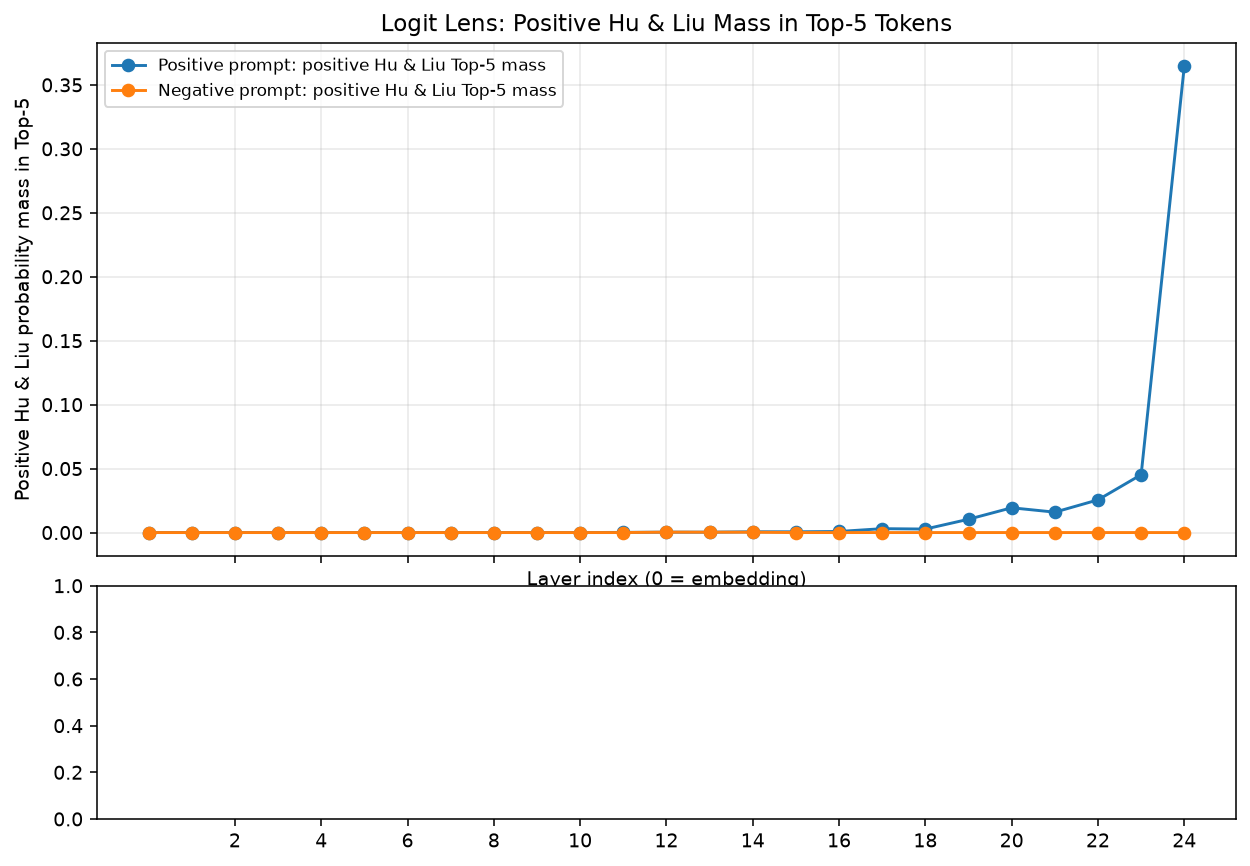

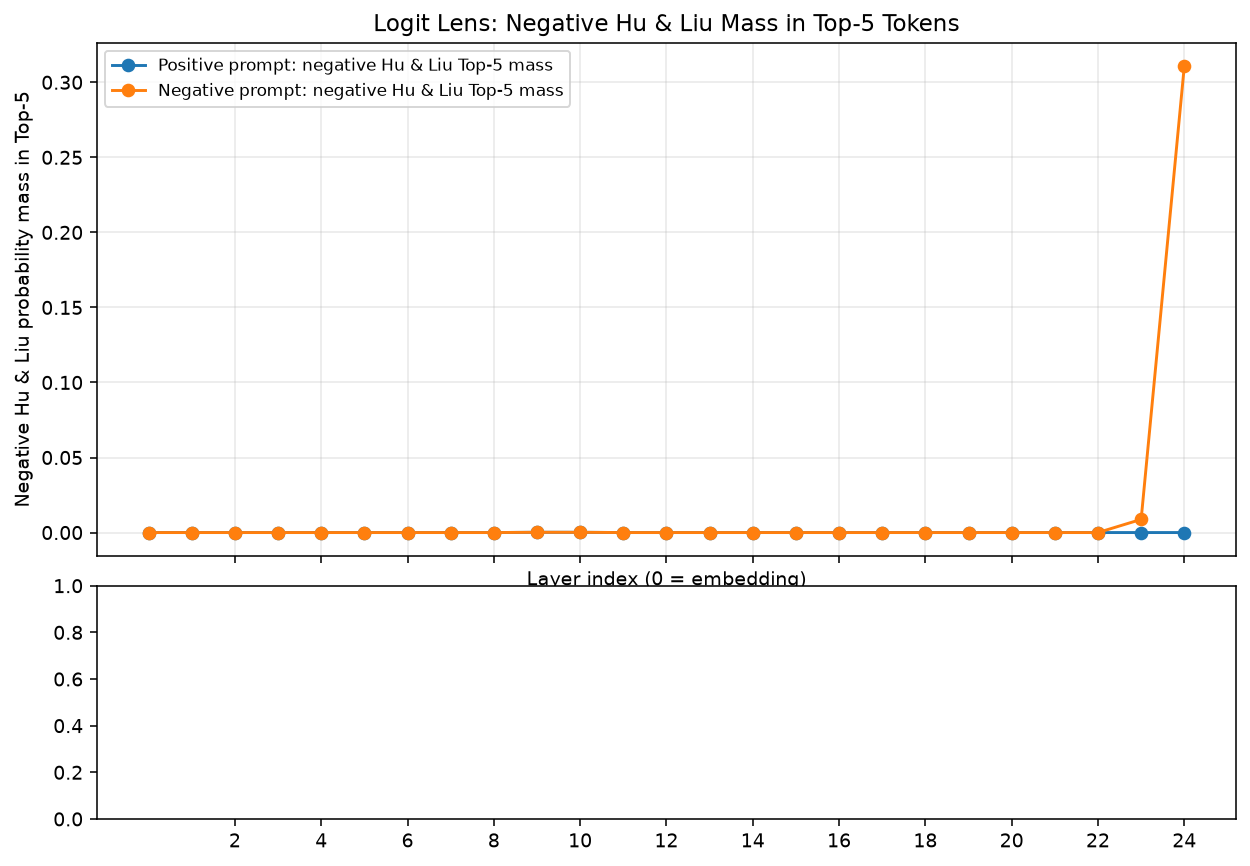

In [16]:
# Analyze the Top-k Logit Lens tokens for both prompts as a pair.
# Graph 1: compare both prompts against positive Hu & Liu words.
# Graph 2: compare both prompts against negative Hu & Liu words.
top_k_sentiment_mass_results = analyze_hu_liu_sentiment_probability_mass(
    positive_layer_results,
    negative_layer_results,
    hu_liu_sentiment_state,
    prompt_pair,
    top_n=5,
    positive_filename_or_path=config.LOGIT_LENS_POSITIVE_SENTIMENT_MASS_PATH,
    negative_filename_or_path=config.LOGIT_LENS_NEGATIVE_SENTIMENT_MASS_PATH,
)

# Display the PNGs saved by the plotting utility. Keeping display separate from
# plotting makes reruns deterministic and avoids rewriting unchanged images.
display_image(config.LOGIT_LENS_POSITIVE_SENTIMENT_MASS_PATH.name)
display_image(config.LOGIT_LENS_NEGATIVE_SENTIMENT_MASS_PATH.name)


### Ergebnisinterpretation

Die Logit-Lens-Analyse zeigt, dass Sentiment-Informationen in Pythia-410M schrittweise über die Transformer-Schichten aufgebaut werden. In den frühen Schichten unterscheiden sich positive und negative Prompts kaum und enthalten nahezu keine sentimentbezogenen Top-Vorhersagen.

Erste schwache Sentiment-Signale treten in den mittleren Schichten auf, während eine deutliche Trennung zwischen positiven und negativen Repräsentationen erst in den letzten Schichten sichtbar wird. Die Wahrscheinlichkeit sentimentkonsistenter Wörter steigt insbesondere in den finalen Transformer-Schichten stark an.

Diese Ergebnisse deuten darauf hin, dass Sentiment nicht direkt in den Eingaberepräsentationen kodiert ist, sondern durch die Verarbeitung über mehrere Schichten hinweg entsteht und in den tiefen Schichten des Modells konsolidiert wird.


## 6. Heatmaps: Top-5 Token je Schicht


Unchanged file: logit_lens_positive_topk_heatmap.png
Unchanged file: logit_lens_negative_topk_heatmap.png


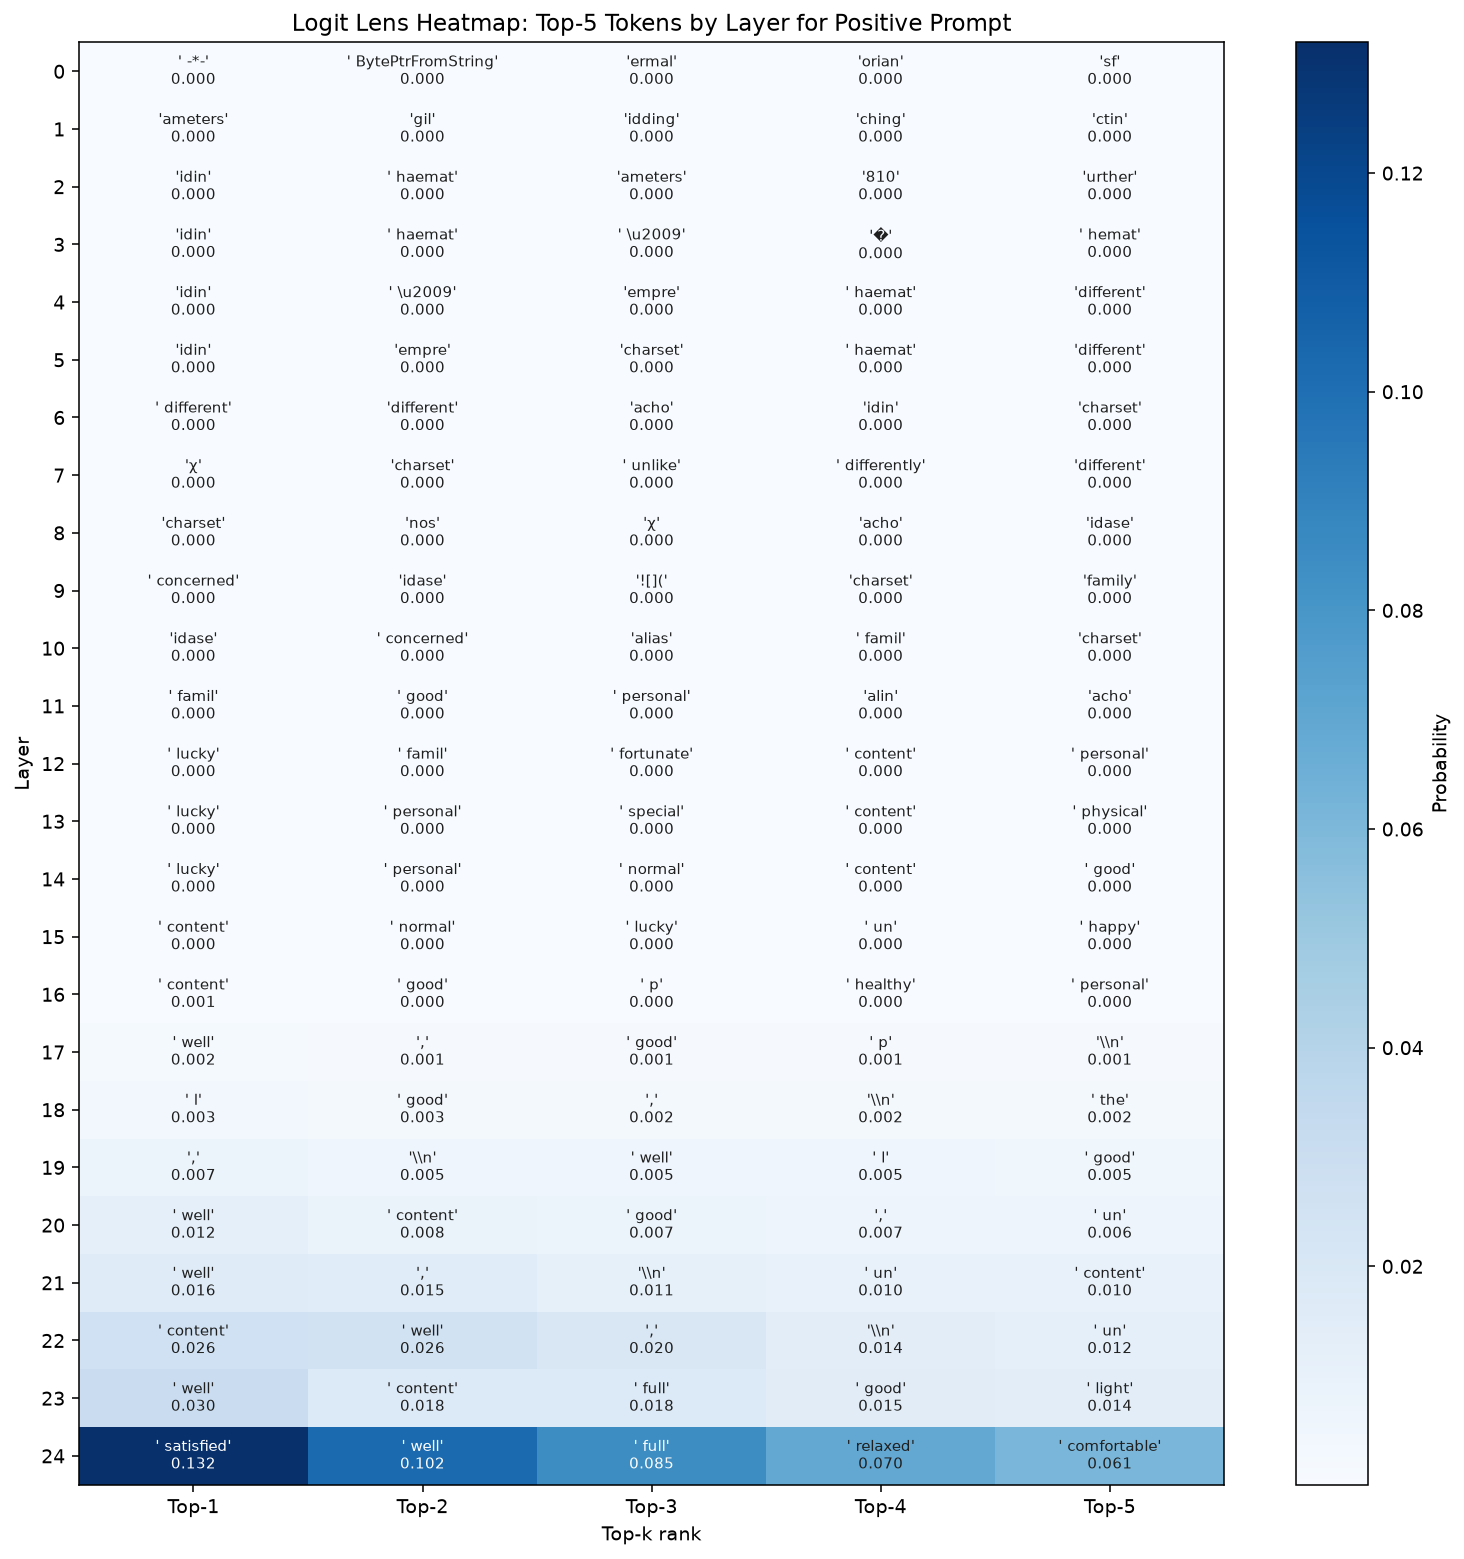

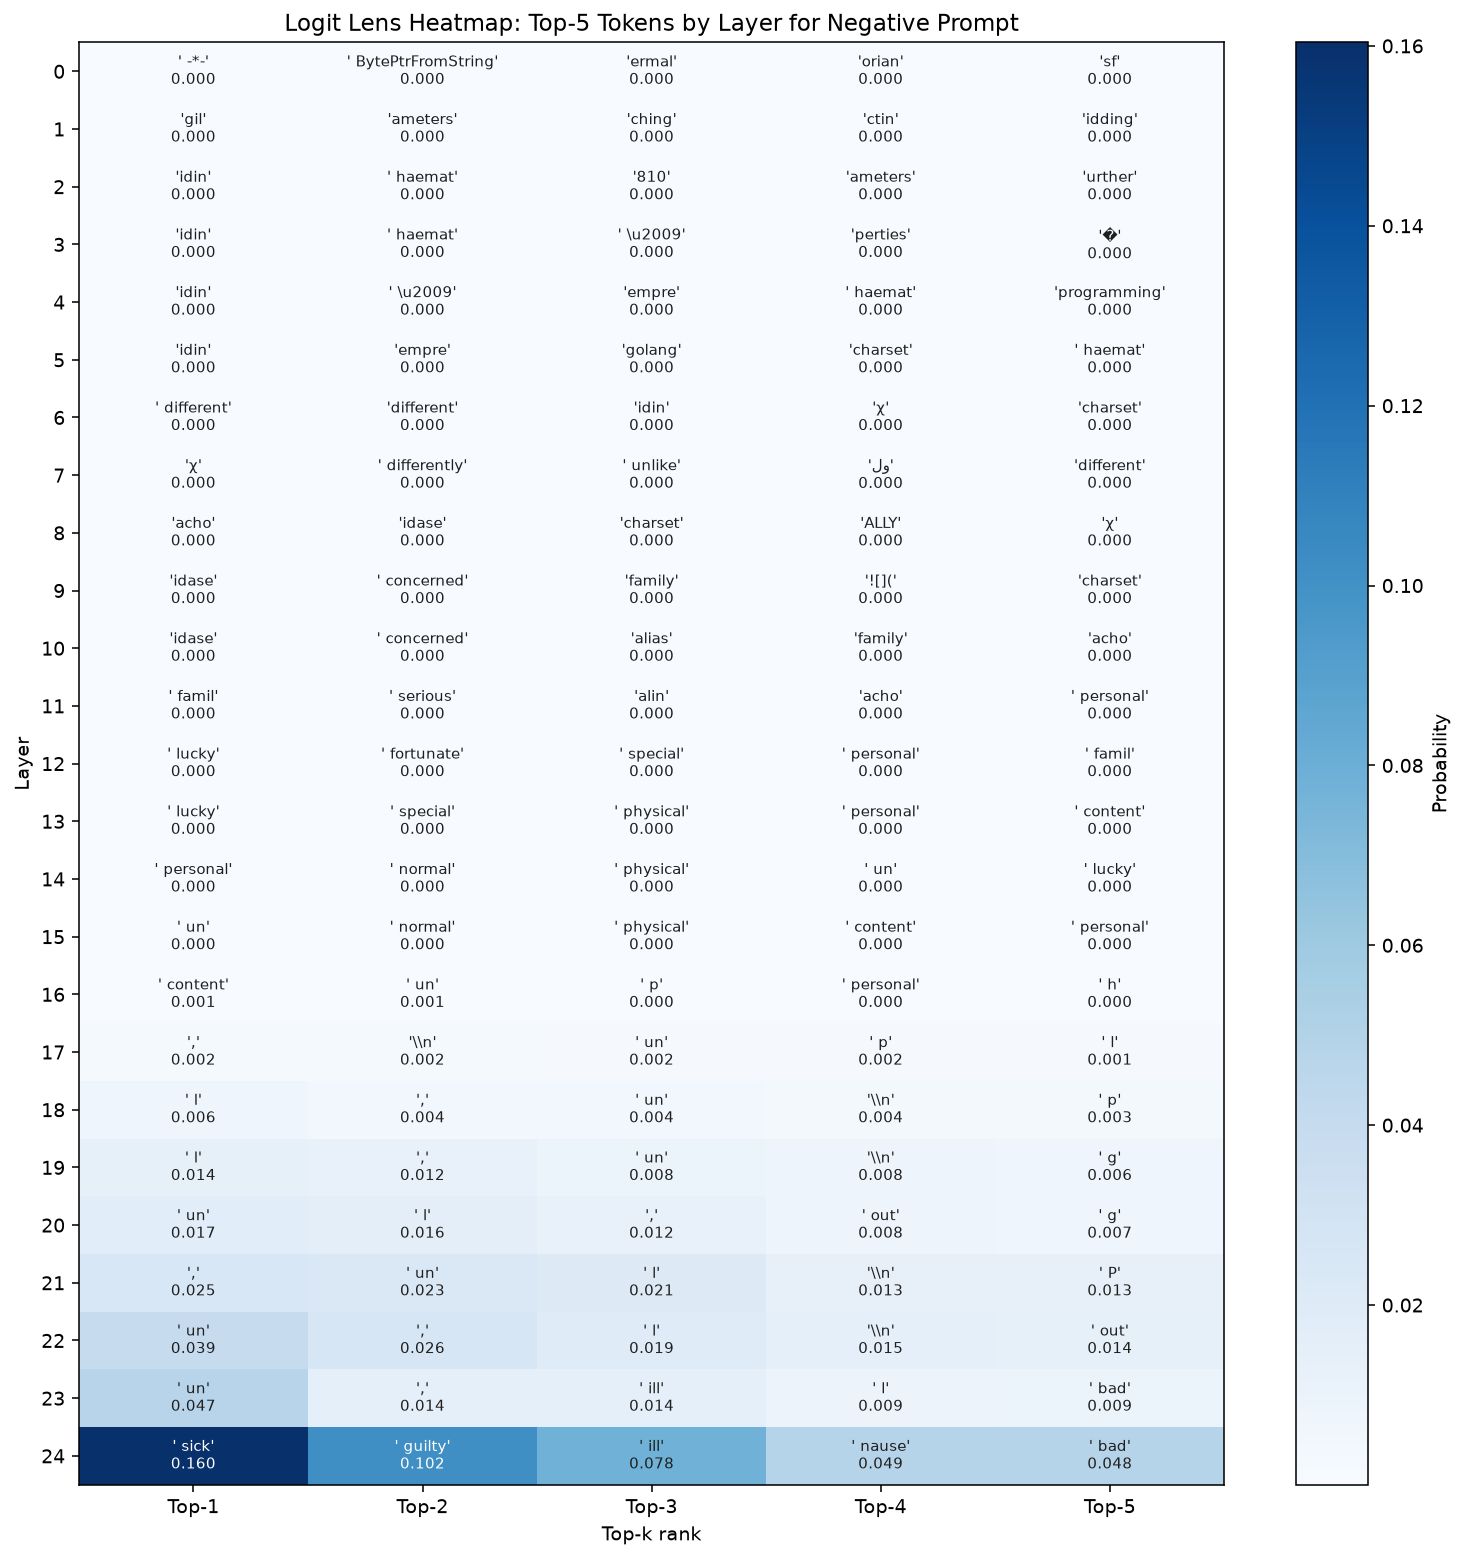

In [17]:
# Save top-5 token heatmaps for the positive and negative prompts. Each row is
# one layer and each column is the token rank within that layer's top-k list.
save_logit_lens_heatmaps(positive_layer_results, negative_layer_results)

# Display the generated heatmaps from the shared output PNG directory.
display_image(config.LOGIT_LENS_POSITIVE_HEATMAP_PATH.name)
display_image(config.LOGIT_LENS_NEGATIVE_HEATMAP_PATH.name)


### Ergebnisinterpretation

Die Heatmaps zeigen, dass die Top-5-Vorhersagen in den frühen und mittleren Schichten überwiegend aus wenig interpretierbaren oder generischen Tokens bestehen. Die Wahrscheinlichkeiten sind dabei sehr gering und die Vorhersagen ändern sich häufig zwischen den Schichten. Dies deutet darauf hin, dass die internen Repräsentationen in diesen Schichten noch keine stabile semantische Bedeutung besitzen.

Ab etwa Schicht 17 steigt die Wahrscheinlichkeit der Top-Vorhersagen deutlich an. Gleichzeitig werden die Vorhersagen konsistenter und konzentrieren sich auf wenige dominante Tokens. Die stärkste Konzentration der Wahrscheinlichkeitsmasse tritt in den letzten Transformer-Schichten auf, insbesondere in der finalen Schicht.

Insgesamt unterstützen die Heatmaps die Ergebnisse der vorherigen Logit-Lens-Analysen: Semantische und sentimentbezogene Informationen werden erst in den späten Transformer-Schichten deutlich sichtbar und in der finalen Vorhersage konsolidiert.


## 7. Logit Difference als Sentiment Score pro Schicht

Um die Entwicklung von Sentiment-Repräsentationen über die Transformer-Schichten hinweg zu untersuchen, wird für jede Schicht ein Sentiment Score auf Basis der Roh-Logits berechnet. Dabei werden alle positiven und negativen Wörter aus dem Hu-&-Liu-Sentiment-Lexikon berücksichtigt.

Der Sentiment Score einer Schicht ergibt sich aus der Differenz zwischen der Summe aller Logits positiver Wörter und der Summe aller Logits negativer Wörter:

$$ Sentiment Score = Logit Difference = \sum_{i=1}^{N_{pos}} Logit(token_i^{pos}) - \sum_{j=1}^{N_{neg}} Logit(token_j^{neg}) $$

Hierbei bezeichnet $N_{pos}$ die Anzahl der positiven Wörter und $N_{neg}$ die Anzahl der negativen Wörter im verwendeten Sentiment-Lexikon. Für jedes dieser Wörter wird der zugehörige Logit-Wert aus der mittels Logit Lens projizierten Schichtrepräsentation entnommen.





Positive prompt
Number of hidden states: 25
Expected: model layers + 1 embedding state
Hidden state 0: (1, 4, 1024)
Hidden state 1: (1, 4, 1024)
Hidden state 2: (1, 4, 1024)
Hidden state 3: (1, 4, 1024)
Hidden state 4: (1, 4, 1024)
Hidden state 5: (1, 4, 1024)
Hidden state 6: (1, 4, 1024)
Hidden state 7: (1, 4, 1024)
Hidden state 8: (1, 4, 1024)
Hidden state 9: (1, 4, 1024)
Hidden state 10: (1, 4, 1024)
Hidden state 11: (1, 4, 1024)
Hidden state 12: (1, 4, 1024)
Hidden state 13: (1, 4, 1024)
Hidden state 14: (1, 4, 1024)
Hidden state 15: (1, 4, 1024)
Hidden state 16: (1, 4, 1024)
Hidden state 17: (1, 4, 1024)
Hidden state 18: (1, 4, 1024)
Hidden state 19: (1, 4, 1024)
Hidden state 20: (1, 4, 1024)
Hidden state 21: (1, 4, 1024)
Hidden state 22: (1, 4, 1024)
Hidden state 23: (1, 4, 1024)
Hidden state 24: (1, 4, 1024)

Negative prompt
Number of hidden states: 25
Expected: model layers + 1 embedding state
Hidden state 0: (1, 4, 1024)
Hidden state 1: (1, 4, 1024)
Hidden state 2: (1, 4, 102

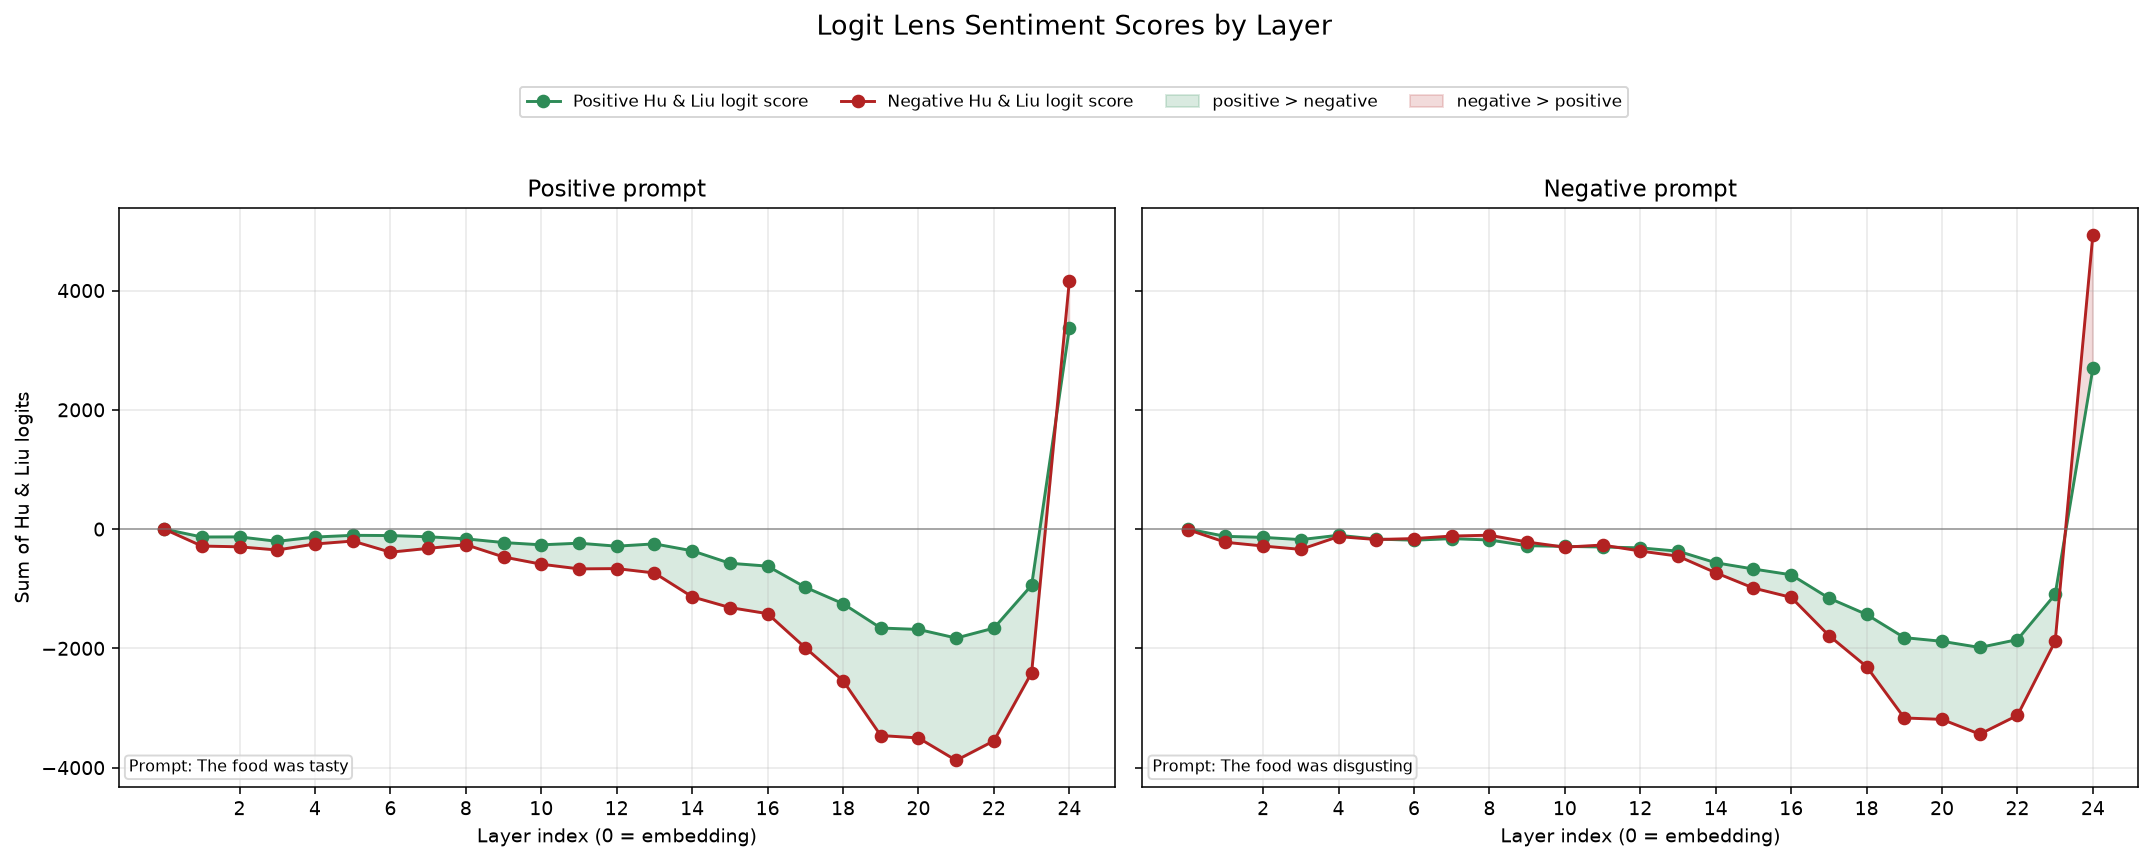

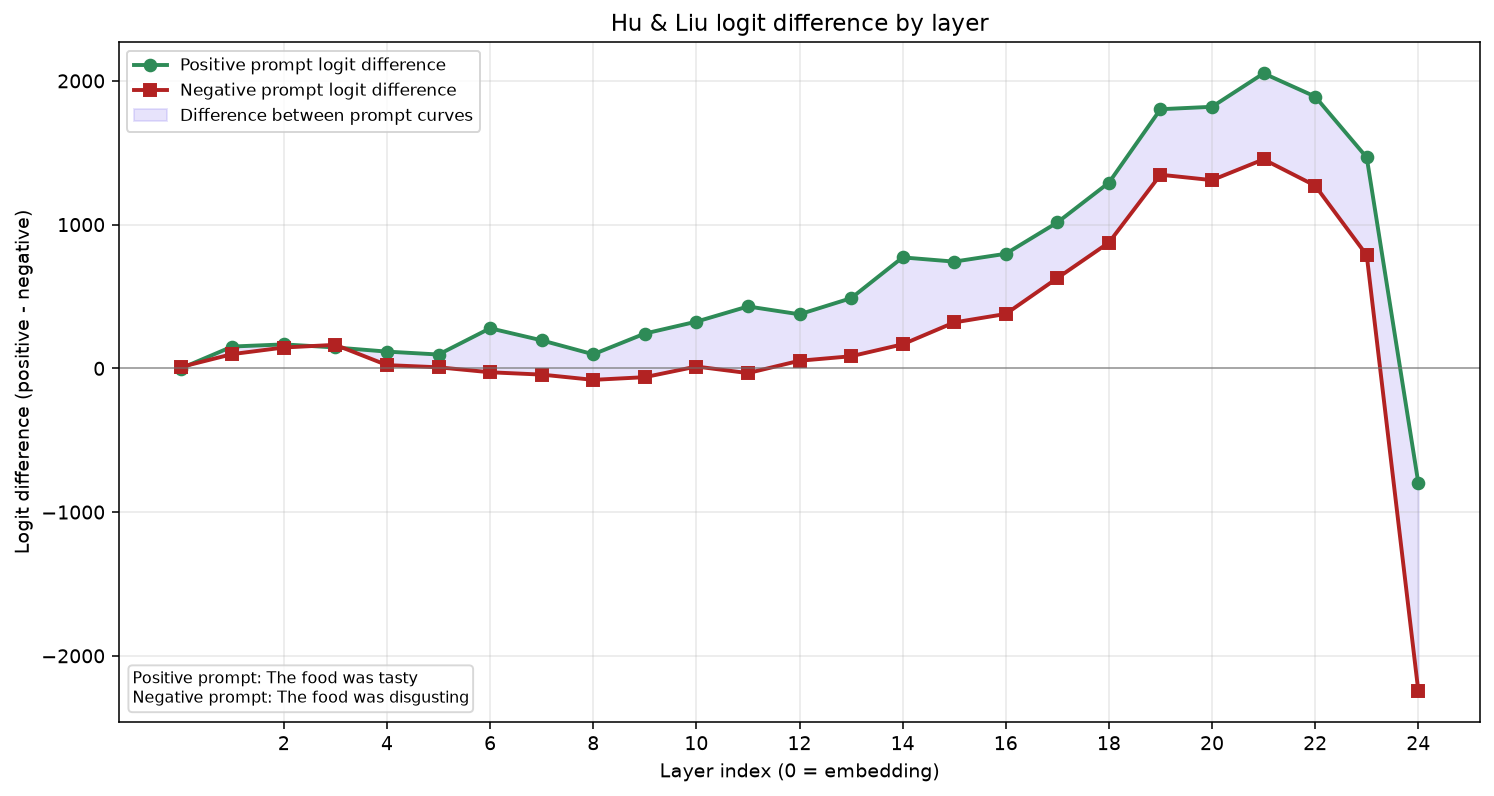


Positive prompt
Number of hidden states: 25
Expected: model layers + 1 embedding state
Hidden state 0: (1, 8, 1024)
Hidden state 1: (1, 8, 1024)
Hidden state 2: (1, 8, 1024)
Hidden state 3: (1, 8, 1024)
Hidden state 4: (1, 8, 1024)
Hidden state 5: (1, 8, 1024)
Hidden state 6: (1, 8, 1024)
Hidden state 7: (1, 8, 1024)
Hidden state 8: (1, 8, 1024)
Hidden state 9: (1, 8, 1024)
Hidden state 10: (1, 8, 1024)
Hidden state 11: (1, 8, 1024)
Hidden state 12: (1, 8, 1024)
Hidden state 13: (1, 8, 1024)
Hidden state 14: (1, 8, 1024)
Hidden state 15: (1, 8, 1024)
Hidden state 16: (1, 8, 1024)
Hidden state 17: (1, 8, 1024)
Hidden state 18: (1, 8, 1024)
Hidden state 19: (1, 8, 1024)
Hidden state 20: (1, 8, 1024)
Hidden state 21: (1, 8, 1024)
Hidden state 22: (1, 8, 1024)
Hidden state 23: (1, 8, 1024)
Hidden state 24: (1, 8, 1024)

Negative prompt
Number of hidden states: 25
Expected: model layers + 1 embedding state
Hidden state 0: (1, 8, 1024)
Hidden state 1: (1, 8, 1024)
Hidden state 2: (1, 8, 102

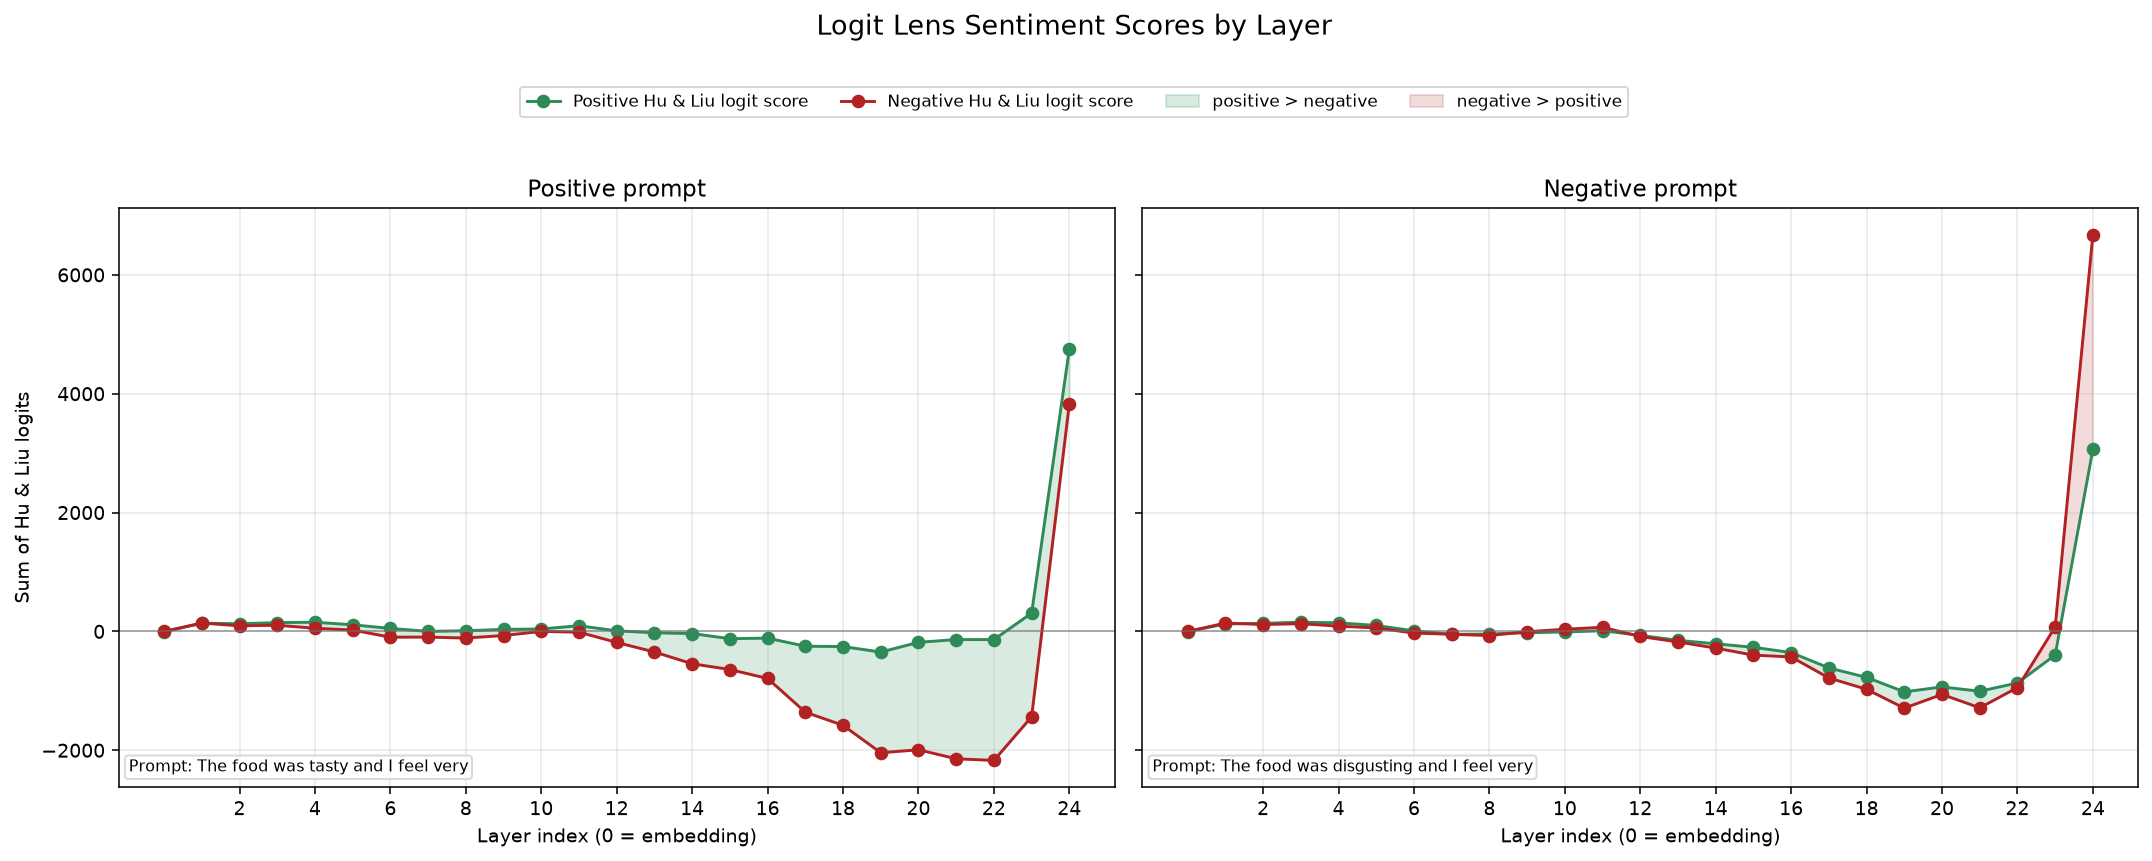

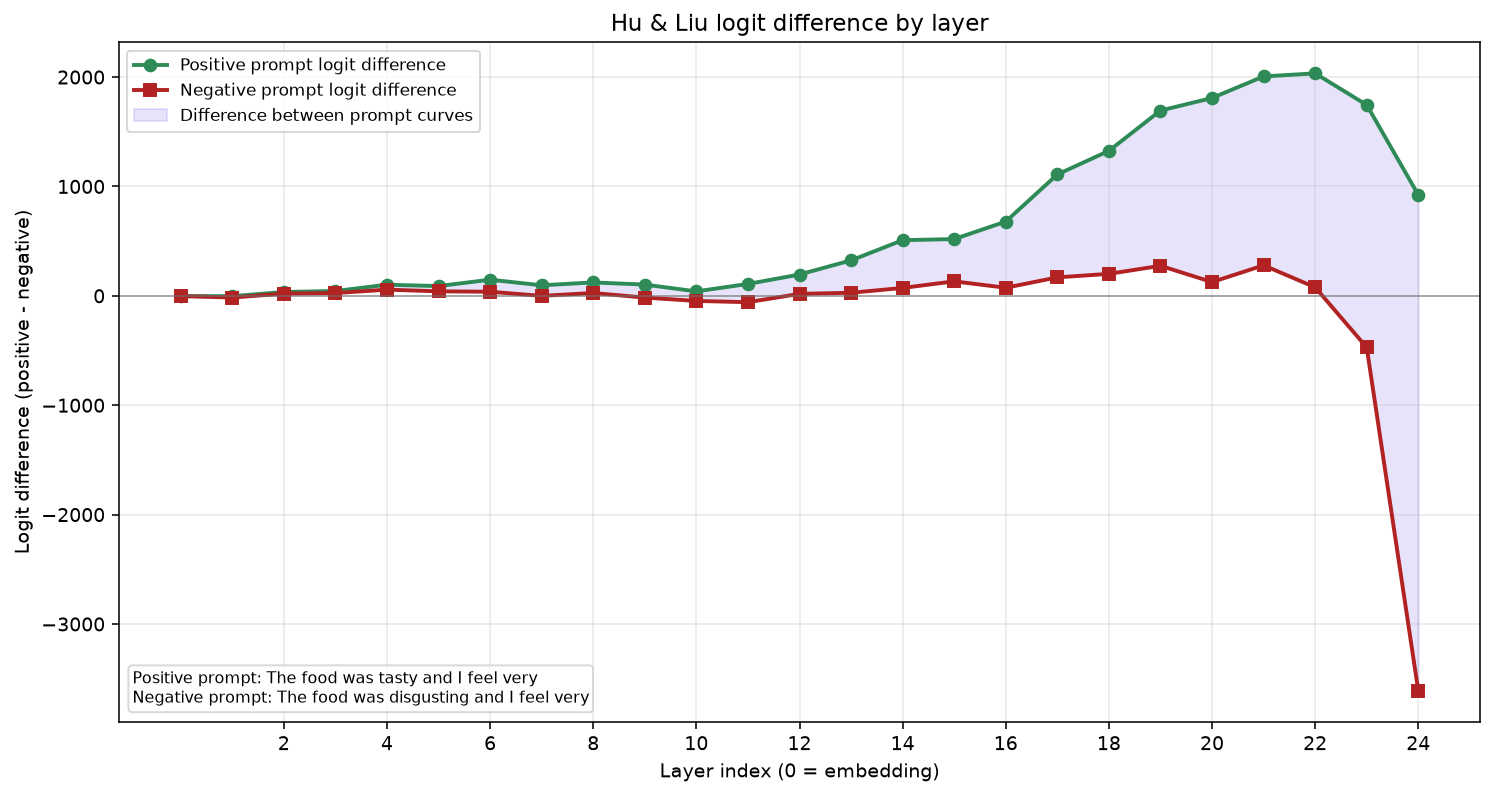

In [35]:
# Define all prompt pairs that should be tested in this chapter.
prompt_pairs = [
    {
        "id": "Trial1",
        "positive": "The food was tasty",
        "negative": "The food was disgusting",
    },
    {
        "id": "Trial2",
        "positive": "The food was tasty and I feel very",
        "negative": "The food was disgusting and I feel very",
    },
]

logit_sentiment_score_results = {}

for trial_index, prompt_pair in enumerate(prompt_pairs, start=1):
    trial_name = prompt_pair.get("id", f"Trial{trial_index}")
    scores_png = f"logit_lens_prompt_hu_liu_logit_scores_{trial_name}.png"
    difference_png = f"logit_lens_prompt_hu_liu_logit_difference_{trial_name}.png"

    # Run both prompts through the model with output_hidden_states=True.
    # The utility returns one hidden-state tensor for the embedding output plus one
    # tensor after each transformer layer, separately for the positive and negative
    # prompt.
    positive_hidden_states, negative_hidden_states = run_prompt_pair_forward_passes(
        model,
        tokenizer,
        device,
        prompt_pair,
    )

    # Calculate Hu & Liu positive and negative logit scores after each layer.
    # The utility saves one side-by-side prompt score plot and one logit-difference plot.
    logit_sentiment_score_results[trial_name] = analyze_hu_liu_logit_sentiment_scores(
        positive_hidden_states,
        negative_hidden_states,
        model,
        hu_liu_sentiment_state,
        prompt_pair,
        scores_filename_or_path=scores_png,
        difference_filename_or_path=difference_png,
    )

    display_image(scores_png)
    display_image(difference_png)


### Ergebnisinterpretation

Die Analyse von dem simplen Prompt-Paar mit hilfe von Logit Lensder und Hu-&-Liu-Logit-Scores zeigt, dass sentimentbezogene Evidenz in Pythia-410M nicht gleichmäßig über alle Schichten verteilt ist. In den frühen Schichten liegen die Logit-Summen für positive und negative Sentiment-Wörter nahe beieinander. Dies deutet darauf hin, dass dort noch keine klare sentimentbezogene Trennung sichtbar ist.

Ab den mittleren bis späten Schichten nimmt die Differenz zwischen positiven und negativen Hu-&-Liu-Logits deutlich zu. Beim positiven Prompt ist zwischen etwa Schicht 18 und 22 eine klare Dominanz positiver Sentiment-Evidenz zu beobachten. Beim negativen Prompt ist die Interpretation komplexer: Über weite Teile der mittleren und späten Schichten bleibt die positive Logit-Summe höher als die negative. Erst in der finalen Schicht kippt die Logit-Differenz deutlich in Richtung negativer Sentiment-Wörter. Dies spricht dafür, dass die negative Sentiment-Information im untersuchten Beispiel erst sehr spät, unmittelbar vor der finalen Token-Vorhersage, stark sichtbar wird.

Ein wichtiger Punkt ist jedoch, dass negative Logit-Werte nicht automatisch negative Sentiment-Bedeutung haben. Ein negativer Logit bedeutet lediglich, dass ein Token einen Rohscore unterhalb von null erhält. Entscheidend ist daher nicht der absolute Wert eines Logits, sondern der relative Unterschied zwischen positiven und negativen Sentiment-Logits.

Zusätzlich ist die Verwendung reiner Logit-Summen mit Vorsicht zu interpretieren. Die positiven und negativen Hu-&-Liu-Wortlisten sind unterschiedlich groß sein und unterschiedliche Tokenisierungs- oder Häufigkeitseffekte aufweisen. Dadurch kann eine Logit-Summe durch die Anzahl der Wörter im Lexikon beeinflusst werden.

Ein weiterer auffälliger Befund ist der starke Umschwung in der finalen Schicht. Während die Schichten 18 bis 22 eine relativ stabile Sentiment-Trennung zeigen, verändert sich die Logit-Differenz in Schicht 24 abrupt. Dies deutet darauf hin, dass die letzte Schicht nicht nur semantische Information repräsentiert, sondern stark auf die konkrete nächste-Token-Vorhersage optimiert ist. Die stabilste interne Sentiment-Repräsentation könnte daher eher in den vorletzten Schichten liegen als direkt in der finalen Ausgabeschicht.

Zusammenfassend zeigen die Kurven, dass Sentiment-Information schrittweise im Modell entsteht, aber ihre Interpretation stark von der gewählten Metrik abhängt. Besonders relevant erscheinen die mittleren bis späten Schichten, insbesondere der Bereich zwischen Schicht 18 und 22.

## 8. Aggregation über Counterfactual Sentiment Dataset

Nachdem der Logit-Difference-basierte Sentiment Score für jede Schicht berechnet wurde, wird die Analyse auf alle Prompt-Paare des Counterfactual Sentiment Dataset angewendet. Jedes Datenbeispiel besteht aus einem positiven und einem negativen Gegenstück, die sich möglichst nur in der Sentiment-Richtung unterscheiden.

Die aggregierte Kurve zeigt, ab welcher Schicht sich positive und negative Prompts systematisch voneinander unterscheiden. Werte nahe Null deuten darauf hin, dass das Modell in dieser Schicht noch keine klare sentimentbezogene Trennung vornimmt. Steigende positive Werte zeigen dagegen, dass die Sentiment-Information im Residual Stream zunehmend sichtbar wird. Die Schicht mit der höchsten durchschnittlichen Score-Differenz kann als der Bereich interpretiert werden, in dem die stärkste sentimentbezogene Trennung auftritt.

Diese Aggregation ist wichtig, weil sie die Analyse robuster macht als die Betrachtung einzelner Beispiele. Statt aus einem einzelnen Prompt-Paar auf das Modellverhalten zu schließen, wird untersucht, ob sich ein konsistentes Muster über viele positive und negative Gegenbeispiele hinweg zeigt.

In [36]:
# TODO implement the aggregation of the data set

## 9. Fazit

Die Logit-Lens-Analyse liefert einen schichtweisen Einblick in die Entstehung von Sentiment-Repräsentationen innerhalb von Pythia-410M. Durch die Projektion der Hidden States in den Vokabularraum konnte beobachtet werden, welche Tokens das Modell in den einzelnen Transformer-Schichten bevorzugt und wie sich diese Präferenzen über die Netzwerktiefe hinweg verändern.

Die Ergebnisse zeigen, dass die frühen Schichten (ca. 0–16) überwiegend unspezifische oder schwer interpretierbare Vorhersagen erzeugen. In diesen Schichten unterscheiden sich positive und negative Prompts kaum, was darauf hindeutet, dass die Repräsentationen hauptsächlich lexikalische und syntaktische Informationen enthalten.

Erste sentimentbezogene Signale werden in den mittleren Schichten sichtbar. Positive Wörter aus dem Hu-&-Liu-Lexikon treten erstmals als Top-Vorhersagen auf, ihre Wahrscheinlichkeiten bleiben jedoch zunächst gering. Dies deutet darauf hin, dass sentimentrelevante Informationen bereits vorhanden sind, jedoch noch keine dominante Rolle für die Vorhersage spielen.

Eine deutliche Trennung zwischen positiven und negativen Prompts entsteht erst in den späten Transformer-Schichten. Die Wahrscheinlichkeit sentimentkonsistenter Wörter steigt dort stark an, während die Heatmaps eine zunehmende Konzentration der Wahrscheinlichkeitsmasse auf wenige dominante Tokens zeigen. In der letzten Schicht werden schließlich klare sentimentbezogene Vorhersagen erzeugt, beispielsweise *satisfied* für positive Prompts und *sick* für negative Prompts.

Die Analyse der positiven und negativen Hu-&-Liu-Wahrscheinlichkeitsmassen bestätigt dieses Bild. Positive Prompts akkumulieren in den letzten Schichten zunehmend Wahrscheinlichkeit auf positive Sentiment-Wörter, während negative Prompts entsprechend negative Sentiment-Wörter bevorzugen. Die stärkste Trennung zwischen beiden Prompt-Klassen wird in den letzten Transformer-Schichten beobachtet.

Insgesamt sprechen alle untersuchten Analysen dafür, dass Sentiment nicht direkt in den Embeddings oder frühen Schichten kodiert ist. Stattdessen entsteht die Sentiment-Repräsentation schrittweise über den Residual Stream und wird in den tiefen Transformer-Schichten konsolidiert. Die letzten Schichten scheinen dabei eine zentrale Rolle für die Umwandlung interner Sentiment-Repräsentationen in konkrete sentimentkonsistente Vorhersagen zu spielen.

Die Logit-Lens-Ergebnisse liefern somit erste Evidenz dafür, dass Sentiment in Pythia-410M als verteilte und schichtübergreifende Repräsentation vorliegt. Diese Beobachtung motiviert die nachfolgenden Analysen mittels Attention Analysis, Linear Probing und Activation Patching, um die Träger und Ursachen dieser Sentiment-Repräsentationen genauer zu untersuchen.

## 10. Literaturverzeichnis
### Hu & Liu Opinion Lexicon
Hu, M., & Liu, B. (2004). Mining and Summarizing Customer Reviews. Proceedings of the ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD).
- Link: https://www.cs.uic.edu/~liub/publications/kdd04-revSummary.pdf
- Datensatz Link: https://www.cs.uic.edu/~liub/FBS/sentiment-analysis.html
- Verwendung: Das Hu-&-Liu-Opinion-Lexikon enthält Listen positiver und negativer Wörter. In dieser Arbeit wird es verwendet, um sentimentbezogene Tokens zu identifizieren und daraus Logit-basierte Sentiment-Scores über die Transformer-Schichten von Pythia-410M zu berechnen.
### Counterfactually Augmented Data (CAD)
Kaushik, D., Hovy, E., & Lipton, Z. C. (2020). *Learning the Difference that Makes a Difference with Counterfactually-Augmented Data*. International Conference on Learning Representations (ICLR).
- Paper Link: https://openreview.net/pdf?id=Sklgs0NFvr
- GitHub Link: https://github.com/acmi-lab/counterfactually-augmented-data
- Verwendung: Der Datensatz enthält originale und gegenfaktische Sentiment-Beispiele, die sich nur durch minimale Änderungen sentimenttragender Wörter unterscheiden. Dadurch eignet er sich besonders für die Untersuchung von Sentiment-Repräsentationen, da positive und negative Beispiele nahezu identischen Kontext besitzen. In dieser Arbeit wird der Datensatz verwendet, um die Entwicklung sentimentbezogener Repräsentationen mittels Logit Lens sowie die kausale Bedeutung einzelner Modellkomponenten durch Activation Patching zu analysieren.
